# Prédiction des prix Airbnb — ESILV A3

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn — Pipeline et préprocessing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import TargetEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics import r2_score

# Modèles
from sklearn.svm import LinearSVR
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb

# Style des graphiques
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("Imports OK")

Imports OK


---
## 1. Exploration des données

On commence par charger et inspecter les données avant toute modélisation. L'objectif est de comprendre la structure du dataset, repérer les valeurs manquantes, et identifier les features les plus corrélées à la variable cible `log_price`.

In [58]:
train = pd.read_csv("Airbnb/airbnb_train.csv")
test  = pd.read_csv("Airbnb/airbnb_test.csv")

print(f"Train : {train.shape[0]:,} lignes, {train.shape[1]} colonnes")
print(f"Test  : {test.shape[0]:,} lignes, {test.shape[1]} colonnes")
train.head(3)

Train : 22,234 lignes, 28 colonnes
Test  : 51,877 lignes, 27 colonnes


,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,zipcode,bedrooms,beds
0,5708593,4.317488,House,Private room,"{TV,""Wireless Internet"",Kitchen,""Free parking ...",3,1.0,Real Bed,flexible,False,...,NaN,33.782712,-118.134410,Island style Spa Studio,Long Beach,0,NaN,90804,0.0,2.0
1,14483613,4.007333,House,Private room,"{""Wireless Internet"",""Air conditioning"",Kitche...",4,2.0,Real Bed,strict,False,...,2017-09-17,40.705468,-73.909439,"Beautiful and Simple Room W/2 Beds, 25 Mins to...",Ridgewood,38,86.0,11385,1.0,2.0
2,10412649,7.090077,Apartment,Entire home/apt,"{TV,""Wireless Internet"",""Air conditioning"",Kit...",6,2.0,Real Bed,flexible,False,...,NaN,38.917537,-77.031651,2br/2ba luxury condo perfect for infant / toddler,U Street Corridor,0,NaN,20009,2.0,2.0


In [59]:
train.describe()

,id,log_price,accommodates,bathrooms,latitude,longitude,number_of_reviews,review_scores_rating,bedrooms,beds
count,2.223400e+04,22234.000000,22234.000000,22183.000000,22234.000000,22234.000000,22234.000000,17256.000000,22208.000000,22199.000000
mean,1.122269e+07,4.783481,3.155573,1.236037,38.462971,-92.269305,20.670774,94.069077,1.264769,1.711473
std,6.080480e+06,0.718758,2.143870,0.586246,3.071679,21.670081,37.183731,7.782235,0.852819,1.254903
min,3.362000e+03,2.302585,1.000000,0.000000,33.339002,-122.510940,0.000000,20.000000,0.000000,0.000000
25%,6.202924e+06,4.317488,2.000000,1.000000,34.136082,-118.340633,1.000000,92.000000,1.000000,1.000000
50%,1.217425e+07,4.700480,2.000000,1.000000,40.662632,-76.994944,6.000000,96.000000,1.000000,1.000000
75%,1.639502e+07,5.220356,4.000000,1.000000,40.746358,-73.954599,23.000000,100.000000,1.000000,2.000000
max,2.120450e+07,7.600402,16.000000,8.000000,42.390248,-70.989359,505.000000,100.000000,10.000000,18.000000


### Distribution de la variable cible — `log_price`

`log_price` est le logarithme naturel du prix par nuit. Travailler sur le log plutôt que le prix brut stabilise la variance et rend la distribution plus symétrique, ce qui améliore les modèles de régression.

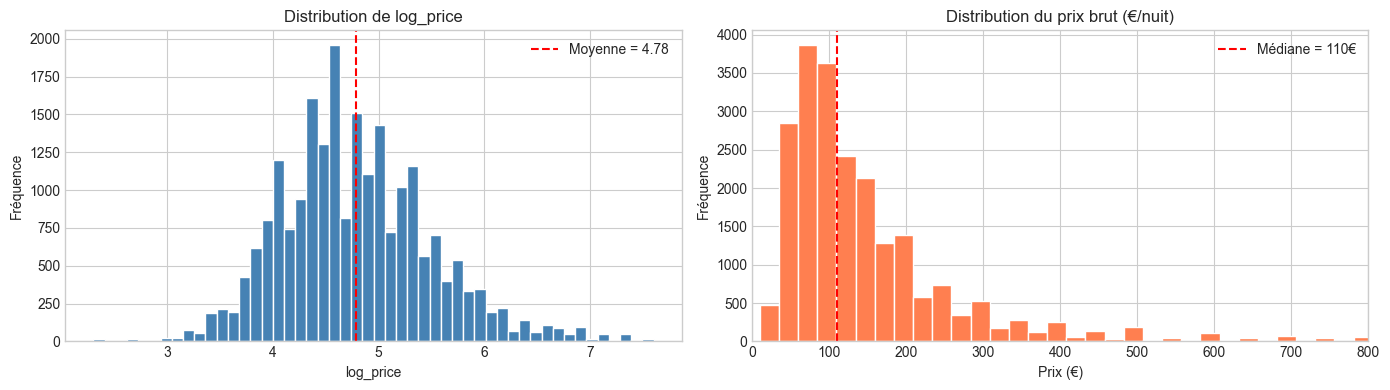

Prix médian : 110€/nuit
Prix moyen  : 161€/nuit
Prix max    : 1999€/nuit


In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution de log_price
axes[0].hist(train['log_price'], bins=50, edgecolor='white', color='steelblue')
axes[0].set_title('Distribution de log_price')
axes[0].set_xlabel('log_price')
axes[0].set_ylabel('Fréquence')
axes[0].axvline(train['log_price'].mean(), color='red', linestyle='--', label=f"Moyenne = {train['log_price'].mean():.2f}")
axes[0].legend()

# Distribution du prix en euros (dé-logarithmé)
prix_brut = np.exp(train['log_price'])
axes[1].hist(prix_brut, bins=80, edgecolor='white', color='coral')
axes[1].set_title('Distribution du prix brut (€/nuit)')
axes[1].set_xlabel('Prix (€)')
axes[1].set_ylabel('Fréquence')
axes[1].set_xlim(0, 800)
axes[1].axvline(prix_brut.median(), color='red', linestyle='--', label=f"Médiane = {prix_brut.median():.0f}€")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Prix médian : {prix_brut.median():.0f}€/nuit")
print(f"Prix moyen  : {prix_brut.mean():.0f}€/nuit")
print(f"Prix max    : {prix_brut.max():.0f}€/nuit")

### Valeurs manquantes

Certaines colonnes ont beaucoup de valeurs manquantes — important à connaître avant de construire le pipeline.

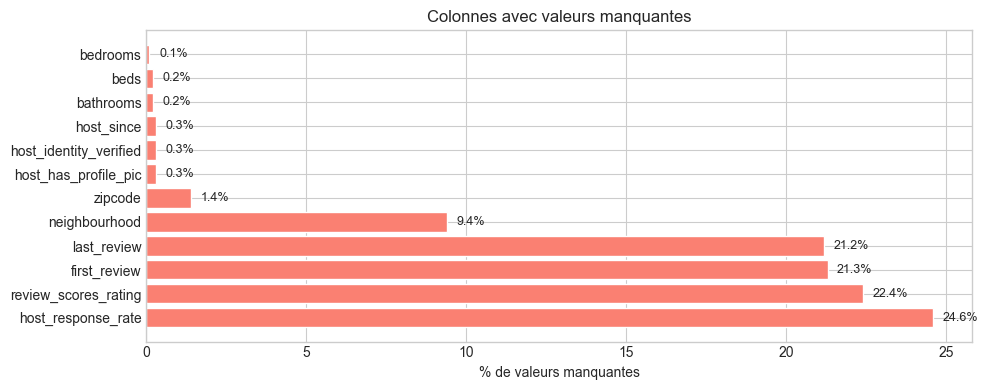

                        manquantes     %
host_response_rate            5475  24.6
review_scores_rating          4978  22.4
first_review                  4725  21.3
last_review                   4716  21.2
neighbourhood                 2086   9.4
zipcode                        303   1.4
host_has_profile_pic            56   0.3
host_identity_verified          56   0.3
host_since                      56   0.3
bathrooms                       51   0.2
beds                            35   0.2
bedrooms                        26   0.1


In [61]:
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(1)
missing_df = pd.DataFrame({'manquantes': missing, '%': missing_pct})
missing_df = missing_df[missing_df['manquantes'] > 0].sort_values('%', ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(missing_df.index, missing_df['%'], color='salmon', edgecolor='white')
ax.set_xlabel('% de valeurs manquantes')
ax.set_title('Colonnes avec valeurs manquantes')
for bar, pct in zip(bars, missing_df['%']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print(missing_df.to_string())

### Corrélations numériques avec `log_price`

La matrice de corrélation montre les relations linéaires entre les variables numériques. Les valeurs proches de 1 ou -1 indiquent une forte corrélation.

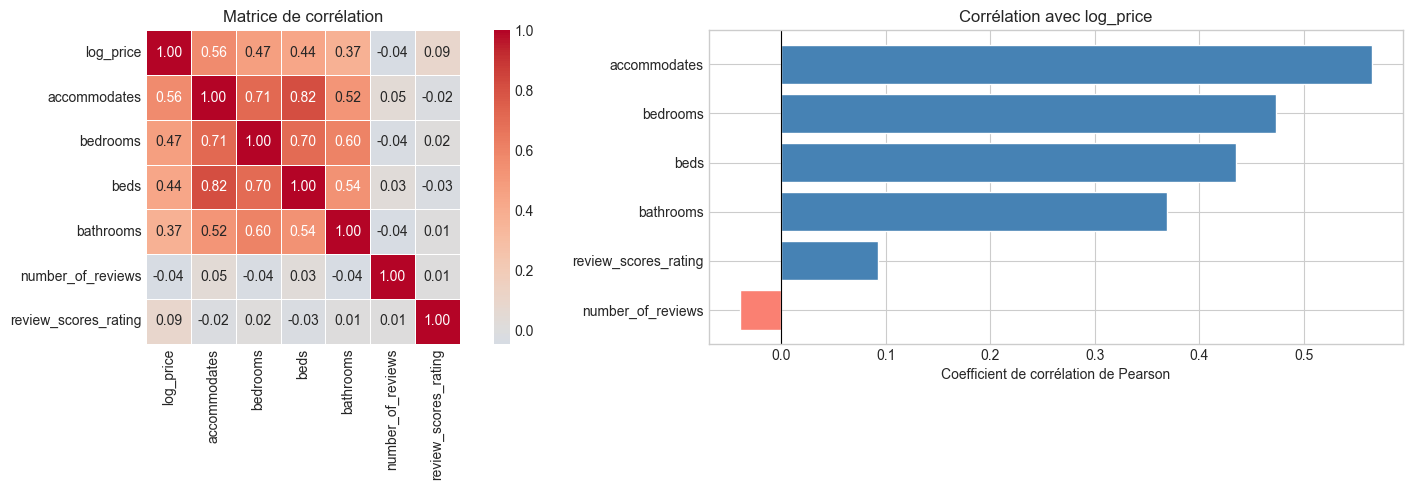

In [62]:
numeric_cols = ['log_price', 'accommodates', 'bedrooms', 'beds',
                'bathrooms', 'number_of_reviews', 'review_scores_rating']

corr = train[numeric_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap complète
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=axes[0], linewidths=0.5)
axes[0].set_title('Matrice de corrélation')

# Corrélation avec log_price uniquement (plus lisible)
corr_target = corr['log_price'].drop('log_price').sort_values(ascending=True)
colors = ['salmon' if v < 0 else 'steelblue' for v in corr_target]
axes[1].barh(corr_target.index, corr_target.values, color=colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Corrélation avec log_price')
axes[1].set_xlabel('Coefficient de corrélation de Pearson')

plt.tight_layout()
plt.show()

### Distribution par variables catégorielles

Pour les variables catégorielles (`city`, `room_type`), on utilise des boxplots : ils montrent la médiane, les quartiles et les outliers de `log_price` pour chaque catégorie.

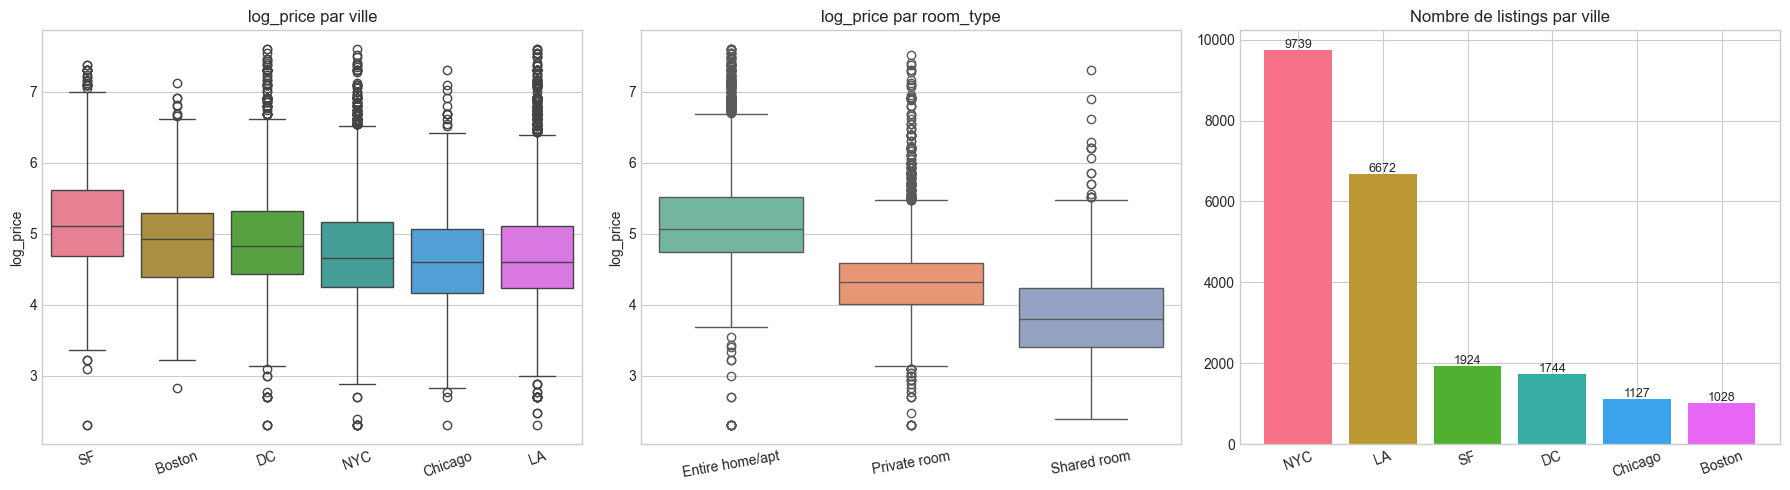

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# log_price par ville
city_order = train.groupby('city')['log_price'].median().sort_values(ascending=False).index
sns.boxplot(data=train, x='city', y='log_price', order=city_order, ax=axes[0], palette='husl')
axes[0].set_title('log_price par ville')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)

# log_price par room_type
room_order = train.groupby('room_type')['log_price'].median().sort_values(ascending=False).index
sns.boxplot(data=train, x='room_type', y='log_price', order=room_order, ax=axes[1], palette='Set2')
axes[1].set_title('log_price par room_type')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=10)

# Nombre de listings par ville
city_counts = train['city'].value_counts()
axes[2].bar(city_counts.index, city_counts.values, color=sns.color_palette('husl', len(city_counts)))
axes[2].set_title('Nombre de listings par ville')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=20)
for i, v in enumerate(city_counts.values):
    axes[2].text(i, v + 50, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## 2. Feature Engineering

L'objectif est de transformer les données brutes en features exploitables par un modèle ML. On construit un **Pipeline sklearn** qui :
1. Parse la colonne `amenities` (string brut → colonnes binaires)
2. Transforme les dates en durées numériques
3. Encode les variables catégorielles (target encoding)
4. Impute les valeurs manquantes

Le principe fondamental : **tout est appris sur le train uniquement** (`fit`), puis appliqué à l'identique sur le test (`transform`). C'est ce qui garantit l'absence de data leakage.

### Transformer 1 — AmenitiesEncoder

La colonne `amenities` contient des strings comme `{TV,"Wireless Internet",Kitchen,...}`. On veut une colonne binaire par amenity (1 = présente, 0 = absente), en ne gardant que les amenities présentes dans plus de 1% des listings pour éviter les features trop rares.

In [64]:
import re
from collections import Counter

class AmenitiesEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, min_freq=0.01):
        self.min_freq = min_freq

    def _parse(self, s):
        if pd.isna(s):
            return set()
        items = re.sub(r'[{}"]', '', str(s)).split(',')
        return {item.strip().lower() for item in items if item.strip()}

    def fit(self, X, y=None):
        counter = Counter()
        all_parsed = X.apply(self._parse)
        for amenity_set in all_parsed:
            counter.update(amenity_set)
        n = len(X)
        self.amenities_ = sorted([a for a, c in counter.items() if c / n >= self.min_freq])
        print(f"  → {len(self.amenities_)} amenities retenues (seuil {self.min_freq*100:.0f}%)")
        return self

    def transform(self, X, y=None):
        parsed = X.apply(self._parse)
        result = {f'amenity_{a}': parsed.apply(lambda s: int(a in s))
                  for a in self.amenities_}
        return pd.DataFrame(result, index=X.index).values

    def get_feature_names_out(self, input_features=None):
        return np.array([f'amenity_{a}' for a in self.amenities_])

# Test rapide
enc_test = AmenitiesEncoder(min_freq=0.01)
enc_test.fit(train['amenities'])
print("Exemples d'amenities retenues :", enc_test.amenities_[:10])

  → 71 amenities retenues (seuil 1%)
Exemples d'amenities retenues : ['24-hour check-in', 'air conditioning', 'bathtub', 'bed linens', 'breakfast', 'buzzer/wireless intercom', 'cable tv', 'carbon monoxide detector', 'cat(s)', 'children’s books and toys']


### Transformer 2 — DateFeatureExtractor

Les colonnes `host_since`, `first_review`, `last_review` sont des dates brutes. On les transforme en durées numériques (en jours) qui ont une signification ML claire : ancienneté de l'hôte, âge du listing, activité récente.

La date de référence est apprise sur le train (`fit`) pour garantir la reproductibilité.

In [65]:
class DateFeatureExtractor(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.ref_date_ = pd.to_datetime(X['last_review'], errors='coerce').max()
        print(f"  → Date de référence : {self.ref_date_.date()}")
        return self

    def transform(self, X, y=None):
        ref = self.ref_date_
        host_since   = pd.to_datetime(X['host_since'],   errors='coerce')
        first_review = pd.to_datetime(X['first_review'],  errors='coerce')
        last_review  = pd.to_datetime(X['last_review'],   errors='coerce')

        host_tenure     = (ref - host_since).dt.days
        listing_age     = (ref - first_review).dt.days
        days_since_last = (ref - last_review).dt.days
        review_velocity = X['number_of_reviews'] / listing_age.clip(lower=1)

        result = pd.DataFrame({
            'host_tenure_days':       host_tenure,
            'listing_age_days':       listing_age,
            'days_since_last_review': days_since_last,
            'review_velocity':        review_velocity,
        }, index=X.index)
        return result.values

    def get_feature_names_out(self, input_features=None):
        return np.array(['host_tenure_days', 'listing_age_days',
                         'days_since_last_review', 'review_velocity'])

### Assemblage du Pipeline complet

On combine tous les transformers avec `ColumnTransformer` : chaque groupe de colonnes reçoit son traitement spécifique. Le `remainder='drop'` ignore automatiquement les colonnes non mentionnées (texte libre, id, etc.).

In [66]:
# Colonnes par type
NUMERIC_COLS = ['accommodates', 'bedrooms', 'beds', 'bathrooms',
                'number_of_reviews', 'review_scores_rating', 'latitude', 'longitude',
                'amenities_count', 'beds_per_person', 'bath_per_person', 'has_reviews']

CATEGORICAL_COLS = ['city', 'room_type', 'property_type', 'neighbourhood',
                    'cancellation_policy', 'bed_type']

BOOL_COLS = ['cleaning_fee', 'host_has_profile_pic',
             'host_identity_verified', 'instant_bookable']

DATE_COLS = ['host_since', 'first_review', 'last_review', 'number_of_reviews']

def clean_data(df):
    """Nettoyage des colonnes problématiques avant le pipeline."""
    df = df.copy()
    df['host_response_rate'] = (
        df['host_response_rate']
        .str.replace('%', '', regex=False)
        .astype(float)
    )
    df['cleaning_fee'] = df['cleaning_fee'].astype(int)
    for col in ['host_has_profile_pic', 'host_identity_verified', 'instant_bookable']:
        df[col] = df[col].map({'t': 1, 'f': 0}).astype(float)

    # Features dérivées
    df['amenities_count'] = df['amenities'].apply(
        lambda s: len(re.sub(r'[{}"]', '', str(s)).split(',')) if pd.notna(s) else 0
    )
    df['has_reviews']     = (df['number_of_reviews'] > 0).astype(int)
    df['beds_per_person'] = df['beds'] / df['accommodates'].clip(lower=1)
    df['bath_per_person'] = df['bathrooms'] / df['accommodates'].clip(lower=1)

    return df

train_clean = clean_data(train)
test_clean  = clean_data(test)

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('encoder', TargetEncoder(smooth='auto', random_state=42))
])

bool_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Les dates manquantes (~21%) produisent des NaN → imputer après extraction
date_pipe = Pipeline([
    ('extractor', DateFeatureExtractor()),
    ('imputer',   SimpleImputer(strategy='median'))
])

preprocessor = ColumnTransformer([
    ('num',       numeric_pipe,       NUMERIC_COLS + ['host_response_rate']),
    ('cat',       categorical_pipe,   CATEGORICAL_COLS),
    ('bool',      bool_pipe,          BOOL_COLS),
    ('amenities', AmenitiesEncoder(min_freq=0.01), 'amenities'),
    ('dates',     date_pipe,          DATE_COLS),
], remainder='drop')

X = train_clean.drop(columns=['id', 'log_price'])
y = train_clean['log_price']

print("Préprocesseur assemblé.")
print(f"X shape : {X.shape}")

Préprocesseur assemblé.
X shape : (22234, 30)


---
## 3. Modèles

On suit une progression volontaire : commencer simple, mesurer le gain à chaque étape. Chaque modèle est évalué par **cross-validation à 5 folds** sur le train — jamais sur le test final.

On utilise `cross_validate` avec `return_train_score=True` pour détecter l'overfitting : si le score train est bien supérieur au score validation, le modèle mémorise les données sans généraliser.

### Modèle 1 — Baseline LinearSVR

Reproduction du modèle fourni, mais avec notre pipeline de features enrichi. Le score de référence avec seulement 3 features était R²≈0.31.

In [67]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

pipeline_svr = Pipeline([
    ('prep',  preprocessor),
    ('model', LinearSVR(max_iter=2000, random_state=42))
])

results_svr = cross_validate(pipeline_svr, X, y, cv=kf,
                              scoring='r2', return_train_score=True)

r2_svr_train = results_svr['train_score'].mean()
r2_svr_val   = results_svr['test_score'].mean()
print(f"LinearSVR — R² train : {r2_svr_train:.3f} | R² val : {r2_svr_val:.3f}")

  → 70 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05
  → 71 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05
  → 71 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05
  → 70 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05
  → 70 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05
LinearSVR — R² train : 0.372 | R² val : 0.361


### Modèle 2 — Random Forest

Première étape vers les modèles ensemblistes. Le Random Forest combine plusieurs centaines d'arbres de décision entraînés sur des sous-ensembles aléatoires des données et des features. Il est plus puissant que LinearSVR car il capture les non-linéarités et les interactions entre features.

In [76]:
pipeline_rf = Pipeline([
    ('prep',  preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=1000,
        max_features='sqrt',
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=42
    ))
])

results_rf = cross_validate(pipeline_rf, X, y, cv=kf,
                             scoring='r2', return_train_score=True)

r2_rf_train = results_rf['train_score'].mean()
r2_rf_val   = results_rf['test_score'].mean()
print(f"Random Forest — R² train : {r2_rf_train:.3f} | R² val : {r2_rf_val:.3f}")

  → 70 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05
  → 71 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05
  → 71 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05
  → 70 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05
  → 70 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05
Random Forest — R² train : 0.777 | R² val : 0.669


### Modèle 3 — LightGBM

LightGBM est un algorithme de **gradient boosting** : contrairement au Random Forest (arbres parallèles indépendants), il construit des arbres séquentiellement où chaque arbre corrige les erreurs du précédent. Plus précis et plus rapide que le Random Forest sur des données tabulaires.

In [69]:
pipeline_lgb = Pipeline([
    ('prep',  preprocessor),
    ('model', lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=20,
        n_jobs=-1,
        random_state=42,
        verbose=-1
    ))
])

results_lgb = cross_validate(pipeline_lgb, X, y, cv=kf,
                              scoring='r2', return_train_score=True)

r2_lgb_train = results_lgb['train_score'].mean()
r2_lgb_val   = results_lgb['test_score'].mean()
print(f"LightGBM — R² train : {r2_lgb_train:.3f} | R² val : {r2_lgb_val:.3f}")

  → 70 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05
  → 71 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05
  → 71 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05
  → 70 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05
  → 70 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05
LightGBM — R² train : 0.919 | R² val : 0.711


### Modèle 4 — LightGBM tuné avec Optuna

Le LightGBM de base montre un gap train/val important (0.914 vs 0.712), signe d'overfitting. **Optuna** explore l'espace des hyperparamètres de façon bayésienne : chaque essai informe le suivant, contrairement au GridSearch qui teste aveuglément toutes les combinaisons. En 50 essais, Optuna trouve typiquement mieux qu'un GridSearch de 1000 combinaisons.

L'objectif : réduire l'overfitting en augmentant la régularisation (`reg_alpha`, `reg_lambda`, `min_child_samples`) tout en gardant un modèle assez expressif.

In [77]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 500, 3000),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        num_leaves        = trial.suggest_int('num_leaves', 31, 200),
        max_depth         = trial.suggest_int('max_depth', 4, 10),
        subsample         = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        min_child_samples = trial.suggest_int('min_child_samples', 20, 200),
        reg_alpha         = trial.suggest_float('reg_alpha', 0.0, 2.0),
        reg_lambda        = trial.suggest_float('reg_lambda', 0.0, 5.0),
    )
    pipe = Pipeline([
        ('prep',  preprocessor),
        ('model', lgb.LGBMRegressor(**params, n_jobs=-1, random_state=42, verbose=-1))
    ])
    res = cross_validate(pipe, X, y, cv=kf, scoring='r2', return_train_score=True)
    return res['test_score'].mean()

# Étude persistante : les trials s'accumulent entre les sessions
study = optuna.create_study(
    study_name="lgb_airbnb",
    storage="sqlite:///optuna_airbnb.db",
    direction='maximize',
    load_if_exists=True  # reprend là où on s'est arrêté
)

n_trials_done = len(study.trials)
print(f"Trials déjà effectués : {n_trials_done} — on en ajoute 20 de plus")

study.optimize(objective, n_trials=20, show_progress_bar=True)

print(f"\nTotal trials : {len(study.trials)}")
print(f"Meilleur R² val : {study.best_value:.3f}")
print("Meilleurs paramètres :", study.best_params)

Trials déjà effectués : 0 — on en ajoute 20 de plus


  0%|          | 0/20 [00:00<?, ?it/s]

  → 70 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05
  → 71 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05
  → 71 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05
  → 70 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05
  → 70 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05


Best trial: 0. Best value: 0.710532:   5%|▌         | 1/20 [01:01<19:36, 61.94s/it]

  → 70 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05
  → 71 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05
  → 71 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05
  → 70 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05
  → 70 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05


...

  → 70 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05
  → 71 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05
  → 71 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05
  → 70 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05
  → 70 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05


Best trial: 12. Best value: 0.717385:  95%|█████████▌| 19/20 [16:01<00:48, 48.08s/it]

  → 70 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05
  → 71 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05
  → 71 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05
  → 70 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05
  → 70 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05


Best trial: 12. Best value: 0.717385: 100%|██████████| 20/20 [16:50<00:00, 50.51s/it]


Total trials : 20
Meilleur R² val : 0.717
Meilleurs paramètres : {'n_estimators': 1181, 'learning_rate': 0.021789095376957928, 'num_leaves': 36, 'max_depth': 8, 'subsample': 0.6077267233046205, 'colsample_bytree': 0.6115190308901886, 'min_child_samples': 37, 'reg_alpha': 1.9208253747566506, 'reg_lambda': 4.922060400510221}


In [71]:
# Réévaluation du meilleur modèle trouvé par Optuna
pipeline_lgb_tuned = Pipeline([
    ('prep',  preprocessor),
    ('model', lgb.LGBMRegressor(**study.best_params, n_jobs=-1, random_state=42, verbose=-1))
])

results_lgb_tuned = cross_validate(pipeline_lgb_tuned, X, y, cv=kf,
                                    scoring='r2', return_train_score=True)

r2_lgb_tuned_train = results_lgb_tuned['train_score'].mean()
r2_lgb_tuned_val   = results_lgb_tuned['test_score'].mean()
print(f"LightGBM tuné — R² train : {r2_lgb_tuned_train:.3f} | R² val : {r2_lgb_tuned_val:.3f}")
print(f"Gain vs LightGBM de base : {r2_lgb_tuned_val - r2_lgb_val:+.3f}")

  → 70 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05
  → 71 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05
  → 71 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05
  → 70 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05
  → 70 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05
LightGBM tuné — R² train : 0.785 | R² val : 0.714
Gain vs LightGBM de base : +0.003


### Interprétabilité — SHAP values

SHAP (SHapley Additive exPlanations) mesure la contribution de chaque feature à chaque prédiction individuelle. Contrairement à `feature_importances_` qui donne une importance globale moyenne, SHAP montre :
- **Quelles features comptent le plus** (importance globale)
- **Dans quel sens** elles influencent le prix (valeur élevée → prix plus haut ou plus bas ?)

C'est l'outil standard d'interprétabilité pour les modèles gradient boosting.

  → 71 amenities retenues (seuil 1%)
  → Date de référence : 2017-10-05


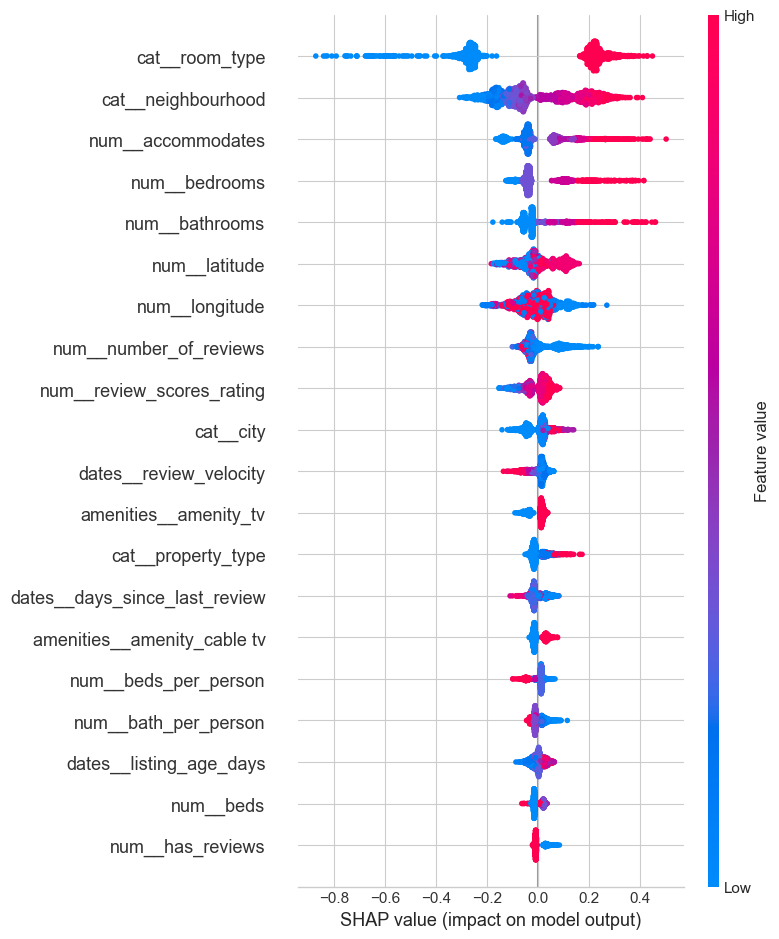

In [72]:
import shap

# Entraîner le meilleur pipeline sur tout le train pour SHAP
pipeline_lgb_tuned.fit(X, y)
lgb_model = pipeline_lgb_tuned.named_steps['model']

# Transformer X avec le preprocessor pour obtenir la matrice de features
X_proc = pipeline_lgb_tuned.named_steps['prep'].transform(X)

# Récupérer les noms de features
feature_names = pipeline_lgb_tuned.named_steps['prep'].get_feature_names_out()

# Calcul des SHAP values (sur 2000 lignes pour la rapidité)
explainer   = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_proc[:2000])

# Graphique beeswarm : top 20 features les plus importantes
shap.summary_plot(shap_values, X_proc[:2000],
                  feature_names=feature_names,
                  max_display=20,
                  plot_type='dot')

### Comparaison des modèles

Tableau récapitulatif et visualisation du gain à chaque étape.

                           Modèle  R² train   R² val  Overfitting
LinearSVR (baseline — 3 features)  0.312000 0.318000       -0.006
                    Random Forest  0.776663 0.667802        0.109
                         LightGBM  0.918904 0.711132        0.208
           LightGBM tuné (Optuna)  0.784613 0.713812        0.071


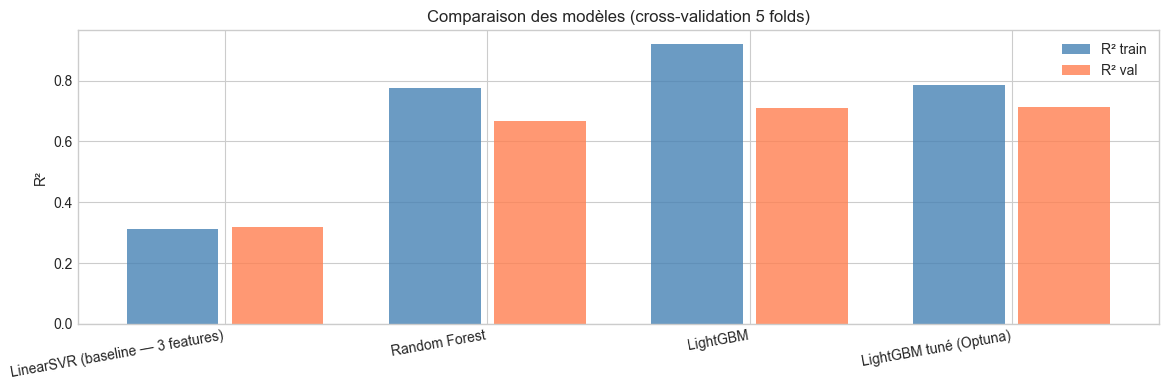

In [73]:
resultats = pd.DataFrame({
    'Modèle':   ['LinearSVR (baseline — 3 features)', 'Random Forest', 'LightGBM', 'LightGBM tuné (Optuna)'],
    'R² train': [0.312, r2_rf_train, r2_lgb_train, r2_lgb_tuned_train],
    'R² val':   [0.318, r2_rf_val,   r2_lgb_val,   r2_lgb_tuned_val],
})
resultats['Overfitting'] = (resultats['R² train'] - resultats['R² val']).round(3)
print(resultats.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 4))
x = range(len(resultats))
ax.bar([i - 0.2 for i in x], resultats['R² train'], width=0.35, label='R² train', color='steelblue', alpha=0.8)
ax.bar([i + 0.2 for i in x], resultats['R² val'],   width=0.35, label='R² val',   color='coral',    alpha=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(resultats['Modèle'], rotation=10, ha='right')
ax.set_ylabel('R²')
ax.set_title('Comparaison des modèles (cross-validation 5 folds)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Prédiction finale

On réentraîne le meilleur modèle (LightGBM) sur **la totalité du train**, puis on prédit sur le jeu de test fourni.

In [74]:
X_test_final = test_clean

# Le pipeline_lgb_tuned est déjà fitté (depuis la cellule SHAP)
# On prédit directement sur le test
y_final = pipeline_lgb_tuned.predict(X_test_final)

# Sauvegarder au format attendu
prediction_example = pd.read_csv("Airbnb/prediction_example.csv")
prediction_example["logpred"] = y_final
prediction_example.to_csv("MaPredictionFinale.csv", index=False)

print(f"Prédictions sauvegardées : {len(y_final)} lignes")
print(f"Aperçu : {y_final[:5].round(3)}")

Prédictions sauvegardées : 51877 lignes
Aperçu : [4.842 5.788 5.036 6.053 4.624]


In [75]:
# Vérification du format de soumission
def estConforme(monFichier_csv):
    votre_prediction = pd.read_csv(monFichier_csv)
    fichier_exemple  = pd.read_csv("Airbnb/prediction_example.csv")
    assert votre_prediction.columns[1] == fichier_exemple.columns[1]
    assert len(votre_prediction) == len(fichier_exemple)
    assert np.all(votre_prediction.iloc[:, 0] == fichier_exemple.iloc[:, 0])
    print("Fichier conforme !")

estConforme("MaPredictionFinale.csv")

Fichier conforme !
